# 🏷️ Notebook 01 — Innholdsbasert filtering

**Popularitetslisten ga Lea blockbustere. Kan metadata gi henne noe bedre?**

Vi prøver den enkleste personlige modellen: bruk det vi *vet* om filmene
til å finne flere som ligner på det Lea allerede liker.
Embeddings og ANN ligger som valgfri appendix til slutt.

## Metadata: nyttig eller bare pent?

Innholdsbasert filtering er som å anbefale bøker basert på omslaget —
det fungerer, men det er begrenset. Vi bygger en brukerprofil fra item-features
som sjanger, tekst eller metadata.

### Styrker

- fungerer for **nye items** uten interaksjonshistorikk
- er lett å forklare og inspisere
- gir ofte god sjangermatch tidlig

### Svakheter

- er begrenset av kvaliteten på features
- kan bli smal og forutsigbar
- ser ikke mønstre som bare blir synlige når mange brukere samspiller

## Oppsett

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
from src.data import load_interactions, load_item_metadata, get_genre_matrix, GENRE_COLS
from src.split import leave_one_out_split, build_sparse_matrix
from src.metrics import recall_at_k, ndcg_at_k

interactions = load_interactions()
items = load_item_metadata()
train_df, test_df = leave_one_out_split(interactions)
n_users = interactions.user_id.max() + 1
n_items = interactions.item_id.max() + 1
train_matrix = build_sparse_matrix(train_df, n_users, n_items)
genre_matrix = get_genre_matrix(items)
user_ids = test_df['user_id'].values
test_items = test_df['item_id'].values
K = 10
LEA_ID = 451

print(f'Genre-matrise: {genre_matrix.shape}')

Genre-matrise: (12169, 19)


## 🏋️ Oppgave 1 — Innholdsbasert som første personalisering

### Hvordan fungerer det?

1. Hver film beskrives som en sjangerfordeling (en rad med tall: 1 for action, 0 for drama, osv.)
2. Vi normaliserer radene slik at lange og korte vektorer kan sammenlignes rettferdig
3. **Brukerprofilen** er gjennomsnittet av sjangerfordelingen til filmene brukeren har sett —
   har Lea sett mye drama og lite action, peker profilen hennes i «drama-retningen»
4. Vi scorer hver usett film med **cosine similarity**: hvor mye overlapper filmens
   sjangervektor med Leas profil? Jo mer overlapp, jo høyere score

Les gjennom koden under og kjør den. Se spesielt på Recall — endrer metadata noe for Lea?

In [2]:
def recommend_content_based(train_matrix, genre_matrix, user_ids, k=10):
    genre_norms = np.linalg.norm(genre_matrix, axis=1, keepdims=True)
    genre_norms = np.where(genre_norms == 0, 1.0, genre_norms)
    item_profiles = genre_matrix / genre_norms
    recommendations = np.zeros((len(user_ids), k), dtype=np.int32)

    for row_index, user_id in enumerate(user_ids):
        seen = train_matrix[user_id].indices
        if len(seen) == 0:
            recommendations[row_index] = np.arange(k)
            continue
        user_profile = item_profiles[seen].mean(axis=0)
        profile_norm = np.linalg.norm(user_profile)
        if profile_norm > 0:
            user_profile = user_profile / profile_norm
        scores = item_profiles @ user_profile
        scores[seen] = -np.inf
        recommendations[row_index] = np.argsort(-scores)[:k]
    return recommendations

In [3]:
item_counts = np.asarray(train_matrix.sum(axis=0)).flatten()
global_ranking = np.argsort(-item_counts)

def recommend_popular(train_matrix, user_ids, k=10):
    recommendations = np.zeros((len(user_ids), k), dtype=np.int32)
    for row_index, user_id in enumerate(user_ids):
        seen = set(train_matrix[user_id].indices)
        unseen_popular = [item_id for item_id in global_ranking if item_id not in seen][:k]
        recommendations[row_index] = unseen_popular
    return recommendations

In [4]:
recs_pop = recommend_popular(train_matrix, user_ids, k=K)
recs_cb = recommend_content_based(train_matrix, genre_matrix, user_ids, k=K)

print(f'Popularitet:    Recall@{K}={recall_at_k(recs_pop, test_items, K):.4f}  NDCG@{K}={ndcg_at_k(recs_pop, test_items, K):.4f}')
print(f'Innholdsbasert: Recall@{K}={recall_at_k(recs_cb, test_items, K):.4f}  NDCG@{K}={ndcg_at_k(recs_cb, test_items, K):.4f}')

Popularitet:    Recall@10=0.0326  NDCG@10=0.0161
Innholdsbasert: Recall@10=0.0035  NDCG@10=0.0015


In [5]:
LEA_ID = 451
JONAS_ID = 102
lea_idx = np.where(user_ids == LEA_ID)[0]
jonas_idx = np.where(user_ids == JONAS_ID)[0]

for uid, name, idx in [(LEA_ID, 'Lea', lea_idx), (JONAS_ID, 'Jonas', jonas_idx)]:
    if len(idx) > 0:
        for model_name, recs in [('Popularitet', recs_pop), ('Innholdsbasert', recs_cb)]:
            rec_items = recs[idx[0]]
            titles = items.set_index('item_id').loc[rec_items, 'title'].values
            print(f'\n{name} — {model_name}:')
            for rank, title in enumerate(titles, 1):
                print(f'  {rank:>2}. {title}')


Lea — Popularitet:
   1. Forrest Gump (1994)
   2. Matrix, The (1999)
   3. Star Wars: Episode IV - A New Hope (1977)
   4. Jurassic Park (1993)
   5. Star Wars: Episode V - The Empire Strikes Back (1980)
   6. Braveheart (1995)
   7. Fight Club (1999)
   8. Terminator 2: Judgment Day (1991)
   9. Schindler's List (1993)
  10. Lord of the Rings: The Fellowship of the Ring, The (2001)

Lea — Innholdsbasert:
   1. Bang, Bang, You're Dead (2002)
   2. Woman of Paris, A (1923)
   3. Cleo from 5 to 7 (Cléo de 5 à 7) (1962)
   4. American Gigolo (1980)
   5. Blow-Out (La grande bouffe) (1973)
   6. Sunset Limited, The (2011)
   7. Desert Flower (2009)
   8. Submarino (2010)
   9. Man with the Golden Arm, The (1955)
  10. Elizabeth I (2005)

Jonas — Popularitet:
   1. Forrest Gump (1994)
   2. Pulp Fiction (1994)
   3. Shawshank Redemption, The (1994)
   4. Silence of the Lambs, The (1991)
   5. Star Wars: Episode IV - A New Hope (1977)
   6. Jurassic Park (1993)
   7. Star Wars: Episode V -

> 💬 **Diskuter**
>
> 1. Hjelper metadata Lea mer enn Jonas? Hvorfor gjør den det?
> 2. Når er innholdsbasert filtering spesielt nyttig i praksis?
> 3. Hva er den største svakheten ved å bruke bare metadata?

## 🏋️ Oppgave 1b — Eksperimenter med vekting

Innholdsbasert-modellen bruker `mean` over alle filmene brukeren har sett.
Hva skjer om vi vekter nyere filmer høyere? Fyll inn `???` under og kjør.

In [6]:
def recommend_cb_weighted(train_matrix, genre_matrix, user_ids, interactions, k=10):
    """Innholdsbasert med recency-vekting. Fyll inn koden som mangler."""
    genre_norms = np.linalg.norm(genre_matrix, axis=1, keepdims=True)
    genre_norms = np.where(genre_norms == 0, 1.0, genre_norms)
    item_profiles = genre_matrix / genre_norms
    recommendations = np.zeros((len(user_ids), k), dtype=np.int32)

    for row_index, user_id in enumerate(user_ids):
        seen = train_matrix[user_id].indices
        if len(seen) == 0:
            recommendations[row_index] = np.arange(k)
            continue

        # --- FYLL INN ---
        # I stedet for ren mean, vekt de siste N filmene høyere.
        # Hint: bruk interactions for å finne rekkefølge,
        # og gi de siste 10 filmene dobbel vekt.
        user_profile = item_profiles[seen].mean(axis=0)  # ← erstatt med vektet versjon
        # ----------------

        profile_norm = np.linalg.norm(user_profile)
        if profile_norm > 0:
            user_profile = user_profile / profile_norm
        scores = item_profiles @ user_profile
        scores[seen] = -np.inf
        recommendations[row_index] = np.argsort(-scores)[:k]
    return recommendations

recs_cb_w = recommend_cb_weighted(train_matrix, genre_matrix, user_ids, interactions, k=K)
print(f'CB vektet: Recall@{K}={recall_at_k(recs_cb_w, test_items, K):.4f}')
print('Hint: resultatet er likt som vanlig CB akkurat nå — det er meningen.')

CB vektet: Recall@10=0.0035
Hint: resultatet er likt som vanlig CB akkurat nå — det er meningen.


### 💡 Fasit — Oppgave 1b

> **Prøv selv først.** Rull ned kun når du har gjort et forsøk.

---

In [7]:
# FASIT — recency-vektet brukerprofil
#
# Idé: finn de siste 10 filmene brukeren så (sortert på timestamp)
# og gi dem dobbel vekt i gjennomsnittet.

def recommend_cb_weighted_fasit(train_matrix, genre_matrix, user_ids, interactions, k=10):
    genre_norms = np.linalg.norm(genre_matrix, axis=1, keepdims=True)
    genre_norms = np.where(genre_norms == 0, 1.0, genre_norms)
    item_profiles = genre_matrix / genre_norms
    recommendations = np.zeros((len(user_ids), k), dtype=np.int32)

    for row_index, user_id in enumerate(user_ids):
        seen = train_matrix[user_id].indices
        if len(seen) == 0:
            recommendations[row_index] = np.arange(k)
            continue

        # Finn de siste 10 filmene sortert på timestamp
        user_history = interactions[interactions.user_id == user_id].sort_values('timestamp')
        recent_items = set(user_history['item_id'].values[-10:])

        # Gi nylige filmer dobbel vekt
        weights = np.array([2.0 if item_id in recent_items else 1.0 for item_id in seen])
        weights = weights / weights.sum()

        user_profile = (item_profiles[seen] * weights[:, None]).sum(axis=0)
        profile_norm = np.linalg.norm(user_profile)
        if profile_norm > 0:
            user_profile = user_profile / profile_norm
        scores = item_profiles @ user_profile
        scores[seen] = -np.inf
        recommendations[row_index] = np.argsort(-scores)[:k]
    return recommendations

recs_cb_fasit = recommend_cb_weighted_fasit(train_matrix, genre_matrix, user_ids, interactions, k=K)
print(f'CB uvektet: Recall@{K}={recall_at_k(recs_cb, test_items, K):.4f}')
print(f'CB vektet:  Recall@{K}={recall_at_k(recs_cb_fasit, test_items, K):.4f}')
print('\n→ Recency-vekting hjelper ikke alltid på Recall — smaken endrer seg sjelden drastisk.')
print('  Men for brukere i transisjon (ny sjanger) kan det gi bedre treff.')

CB uvektet: Recall@10=0.0035
CB vektet:  Recall@10=0.0036

→ Recency-vekting hjelper ikke alltid på Recall — smaken endrer seg sjelden drastisk.
  Men for brukere i transisjon (ny sjanger) kan det gi bedre treff.


### ✏️ Skriveøvelse

Marte spør: *«Hva er egentlig forskjellen på de to modellene vi har testet?»*

Skriv **to-tre setninger** til Marte som forklarer forskjellen mellom popularitet
og innholdsbasert filtering. Regler:

- Bruk gjerne ord som *profil* og *likhet*, men forklar dem som om Marte aldri har tatt et mattekurs
- Forklar hvorfor den ene hjelper Lea mer enn den andre
- Nevn én situasjon der den innholdsbaserte modellen er spesielt nyttig

> *«Marte, forskjellen er at ...»*

---

> *Marte:* «Greit. Metadata hjelper, men det er fortsatt for grovt.
> Hva skjer når Lea får hjelp av tusenvis av andre brukere som ligner på henne?»

**Neste steg** → `02_collaborative_filtering.ipynb`

## Valgfri appendix — embeddings og ANN

Denne delen kan tas **etter** notebook 02 hvis dere vil koble content-based thinking
til embeddings, visualisering og retrieval i produksjonsskala.

/Users/kenanmahic/Projects/recommender-systems-ws/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 15/15 [00:05<00:00,  2.72it/s]


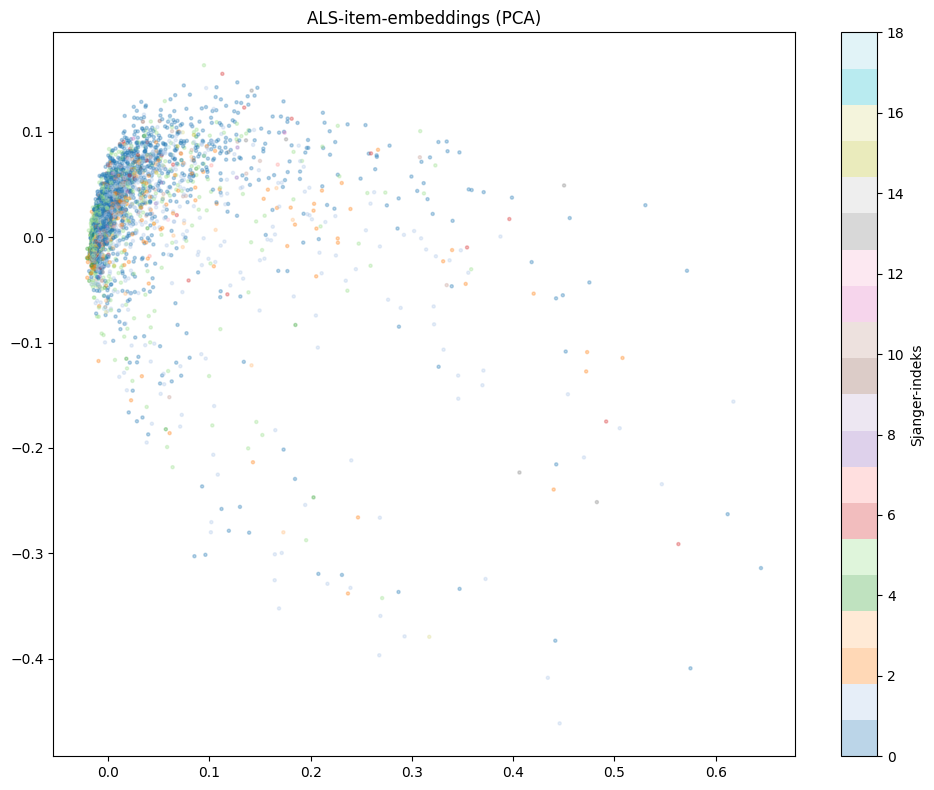

In [8]:
from implicit.als import AlternatingLeastSquares
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

als = AlternatingLeastSquares(factors=64, regularization=0.01, iterations=15, random_state=42, use_gpu=False)
als.fit(train_matrix, show_progress=True)
item_emb = als.item_factors
pca = PCA(n_components=2, random_state=42)
item_2d = pca.fit_transform(item_emb)
dominant_genre = genre_matrix.argmax(axis=1)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(item_2d[:, 0], item_2d[:, 1], c=dominant_genre, cmap='tab20', alpha=0.3, s=5)
ax.set_title('ALS-item-embeddings (PCA)')
plt.colorbar(scatter, ax=ax, label='Sjanger-indeks')
plt.tight_layout()
plt.show()

In [9]:
try:
    import faiss
    emb = np.ascontiguousarray(item_emb.copy(), dtype=np.float32)
    faiss.normalize_L2(emb)
    queries = np.ascontiguousarray(als.user_factors[user_ids], dtype=np.float32)
    faiss.normalize_L2(queries)

    index = faiss.IndexFlatIP(emb.shape[1])
    index.add(emb)
    _, neighbor_ids = index.search(queries, K)
    print(f'FAISS-indeks bygget. Første bruker fikk topp-{K}: {neighbor_ids[0].tolist()}')
except ImportError:
    print('faiss-cpu er ikke installert i dette miljøet.')

FAISS-indeks bygget. Første bruker fikk topp-10: [6410, 6000, 6945, 6077, 4889, 8535, 5165, 2500, 3519, 7077]
